In [10]:
import math
import os
import scipy
from scipy.optimize import lsq_linear
import numpy as np
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, halfnorm
import random
from scipy.io import loadmat
import random
import pickle
import sys
from sklearn.linear_model import RidgeCV
sys.path.append(r"c:\Users\katie\OneDrive\Documents\GitHub\trial")
import PCA_Regress as pcar
from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec

In [11]:
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_neu.pkl', "rb") as input_file:
    J_pickle = pickle.load(input_file)
del input_file

file_path = os.path.join(base_path, 'N_neu.pkl')
with open(file_path, "rb") as input_file:
    N_pickle = pickle.load(input_file)
del input_file

base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_mus.pkl', "rb") as input_file:
    J_pickle_m = pickle.load(input_file)
del input_file

ile_path = os.path.join(base_path, 'N_mus.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m = pickle.load(input_file)
del input_file

# base_path = "/Users/kb6113/Desktop/Thesis"
# with open(base_path+'/J_neu.pkl', "rb") as input_file:
#     J_pickle = pickle.load(input_file)
# del input_file

# with open(base_path+'/J_mus.pkl', "rb") as input_file:
#     J_pickle_m = pickle.load(input_file)
# del input_file

J_all_tensor = J_pickle['J_all']['interpPSTH']
J_M1_tensor = J_pickle['J_M1']['interpPSTH']
J_PMd_tensor = J_pickle['J_PMd']['interpPSTH']
J_idx = np.r_[0:18, 36:45]
J_ntm_tensor = J_all_tensor[J_idx, :, :]
J_mus_tensor = J_pickle_m['interpPSTH']


N_all_tensor = N_pickle['N_all']['interpPSTH']
N_M1_tensor = N_pickle['N_M1']['interpPSTH']
N_PMd_tensor = N_pickle['N_PMd']['interpPSTH']
N_mus_tensor = N_pickle_m['interpPSTH']

<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
C:\Users\katie\AppData\Local\Temp\ipykernel_31928\3800015342.py:2: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_neu.pkl', "rb") as input_file:
C:\Users\katie\AppData\Local\Temp\ipykernel_31928\3800015342.py:12: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_mus.pkl', "rb") as input_file:


[ 2 19 24  9 20 16  1 23  4 17 13 10 18  7  3 25 12 14 11  0 21 26]
>>> best_lam returning: 34.55107294592218


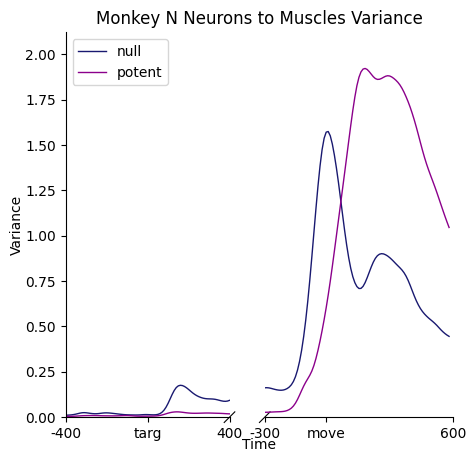

In [12]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor)

[ 8  3 22 18  4  0 13 17 26 12 21  6 25 20 19 14 11  2 23 24  9 10]
>>> best_lam returning: 7.017038286703837


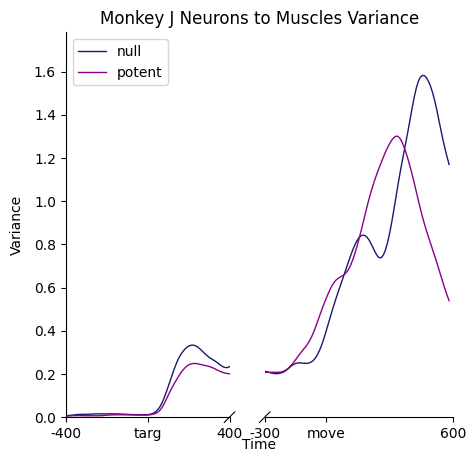

In [13]:
pcar.sup_tuning(J_ntm_tensor, J_mus_tensor)

# best lam = 100

[20 18 26 24 22  0  2 10 21 12 11  6 13  1  5  7 25 23 14 16 19 17]
>>> best_lam returning: 20.30917620904739


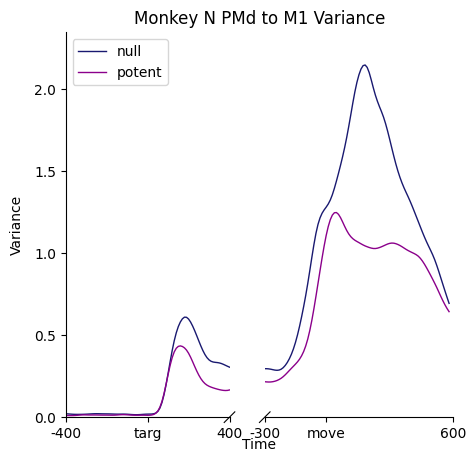

In [14]:
pcar.sup_tuning(N_PMd_tensor, N_M1_tensor, dims = 14) 

# best lam = 58.780160722749116

[ 84  97   2  35  50  78  89  24  86  46  58  77  92   3  64  41  21  57
  65  90  61  26  88 105   1  17  59 103  45  36   7  31  48  76  99  82
  49  69  67  39  51   6   5  27  52  60  53  12  38   0  74  63 102  96
  40  91  13  72  15  34  30  85  54  73 106  93  32 100  25  28  16  14
  37  98  81  23  33   9  22  18  79  20  29  83  56 101  19]
>>> best_lam returning: 11.937766417144381


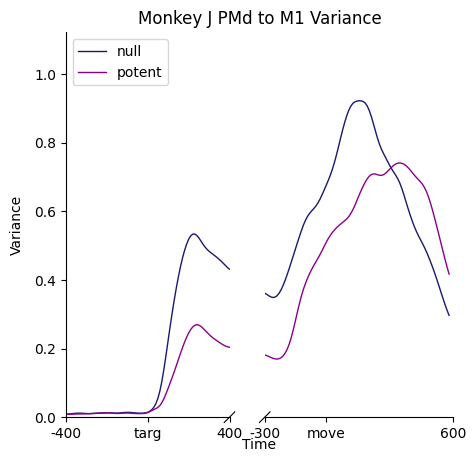

In [15]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[ 90  95 105  28  68  79  15  92  20  61   3  36  24  65  26 106  70  12
  40  53  11  62  31 101  63 107  33   6  87  43  93  50 104   8  80  47
  35  86   1  42  82  69  67  88  96  49  99  78  46  14   2  84  59  18
  81  71  77   7   9  45  19  44  48  27  21   0  23   5  57   4 103  22
  72  54  16  51  75  91  89  34  58  10  76  83  94 102  25]
>>> best_lam returning: 11.937766417144381


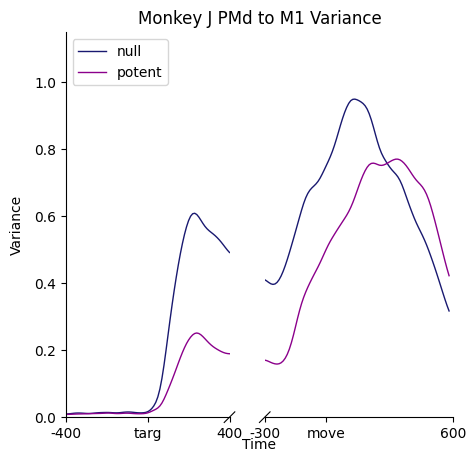

In [16]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[ 1  0 16 19  5 25 21  2 13 24  9 12 18  8 17  4 14 26  6  7 10 22]
>>> best_lam returning: 34.55107294592218


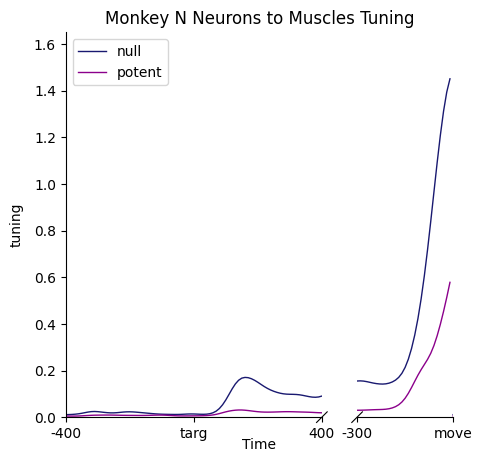

In [17]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor, fig_4D = True)

In [9]:
def fig4_d (tensor_N, tensor_M, dims):

    
    # retrieving dataset specifications 
    J, PMd = pcar.ident(tensor_N)

    # getting weights matrix for potent and null space 
    cond, _, fin_time = tensor_N.shape
    regress_N, _, _ = pcar.time_shift(tensor_N, tensor_M, fig4 = True)
    N_tilde, _, _ = pcar.run_PCA(regress_N, dims)
    W_potent, W_null = pcar.tuning_setup(tensor_N, tensor_M, dims, time = True)
    
    # projecting the neural activity of 400ms before and after target and 300ms before and 800ms after move starts onto the potent and null space of the weights matrix
    N_potent = N_tilde @ W_potent
    N_null = N_tilde @ W_null

    # reshaping into a tensor 
    pot_tensor = pcar.shape_tensor(N_potent, cond)
    null_tensor = pcar.shape_tensor(N_null, cond)
    _, _, time = pot_tensor.shape

    # initializing array for holding the variance 
    V_pot = np.zeros(time)
    V_null = np.zeros(time)
    _, _, time = null_tensor.shape

    ratio = np.zeros(time)

    for t in range(time):

        Xn = null_tensor[:,:,t]
        Xp = pot_tensor[:,:,t]

        # subtract condition mean
        Xn -= Xn.mean(axis=0, keepdims=True)
        Xp -= Xp.mean(axis=0, keepdims=True)

        V_null = np.sum(Xn**2)
        V_pot  = np.sum(Xp**2)

        ratio[t] = (1/gamma) * (V_null / V_pot)